## Introduction to AGENTIC RAG


In this code lab, we build an Agentic Retrieval-Augmented Generation (RAG) system to answer biochemistry questions. The system uses a vector store to retrieve relevant documents from a biochemistry textbook and augments a language model's responses with this context. 
- It maintains conversation history for coherent interactions, acting as a biochemistry tutor with memory.
-  We use LangChain to process a PDF, create a Chroma vector store, and integrate a retrieval tool with LangGraph for agentic behavior.
- By the end, you'll have a tutor that retrieves relevant information and responds intelligently to biochemistry queries!

**Import the neccessary Libraries**

In [ ]:
from langgraph.graph import START, END, StateGraph, MessagesState
from langgraph.checkpoint.memory import MemorySaver
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage
from langchain_together import ChatTogether
from dotenv import load_dotenv
from langgraph.checkpoint.memory import MemorySaver
import os
from langgraph.prebuilt import tools_condition, ToolNode
from IPython.display import Image, display
from langchain_chroma import Chroma
from langchain_core.tools import tool
from typing import Literal


### Set Up Your API Key

**Create a .env file to securely store your API key from Together AI.**


In [ ]:
load_dotenv()
together_api = os.environ.get("TOGETHER_API_KEY")

python-dotenv could not parse statement starting at line 35
python-dotenv could not parse statement starting at line 36


**Initializing the LLM**

we will use the Qwen/Qwen2.5-7B-Instruct-TurboMODEL from Together AI

In [ ]:
llm = ChatTogether(model="Qwen/Qwen2.5-7B-Instruct-Turbo", api_key=together_api)

load in Our pdf

**load the PDF file using PyPDFLoader from LangChain.**

In [ ]:
from langchain_community.document_loaders import PyPDFLoader

file_path ="Lehninger Principles of Biochemistry, 6th Edition ( PDFDrive ) (1) (1).pdf"
loader = PyPDFLoader(file_path)
pages = []
async for page in loader.alazy_load():
    pages.append(page)

In [ ]:
print(pages)

This cell splits the PDF pages into smaller chunks for efficient storage and retrieval in the vector store. We use RecursiveCharacterTextSplitter from LangChain to divide the text into chunks of 1000 characters with a 100-character overlap. 

This ensures no important context is lost between chunks, making retrieval more accurate.

In [ ]:

from langchain.text_splitter import RecursiveCharacterTextSplitter

text_splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=100)
doc_splits = text_splitter.split_documents(pages)


#### Setting Up the Vector Store

This cell sets up a Chroma vector store to store document embeddings for retrieval. We use TogetherEmbeddings to generate embeddings for the text using the Alibaba-NLP/gte-modernbert-base model from Together AI.

In [ ]:
from langchain_together import TogetherEmbeddings

chroma_path = "chroma_store"

embeddings = TogetherEmbeddings(
    model="Alibaba-NLP/gte-modernbert-base",
     api_key=together_api
)

biochemistry_db = Chroma(
   collection_name="biochemistry",
   persist_directory=chroma_path, 
   embedding_function= embeddings)

biochemistry_db.add_documents(
   documents = doc_splits
)

In [ ]:

#add_texts line was an alternative approach that required manually extracting page_content from Document objects

# biochemistry_db.add_texts(
#     texts=[doc.page_content for doc in doc_splits]
# )

**Testing the Retriever**

We configure biochemistry_db as a retriever using Maximum Marginal Relevance (MMR) search, which balances relevance and diversity in results.

In [ ]:
query = "what is Biosynthesis"
retriever = biochemistry_db.as_retriever(search_type="mmr", search_kwargs={"k":5, "fetch_k": 5})
results = retriever.invoke(query)
print (results)

[Document(id='4bbd42c0-3d4c-41fe-87cf-e9ba79ef013c', metadata={'creationdate': '', 'creator': 'PyPDF', 'moddate': '2025-06-07T12:41:46+00:00', 'page': 41, 'page_label': '42', 'producer': 'iLovePDF', 'source': 'Lehninger Principles of Biochemistry, 6th Edition ( PDFDrive ) (1) (1).pdf', 'total_pages': 43}, page_content='22.2 Biosynthesis of Amino Acids 891\n22.2 Biosynthesis of Amino Acids\nAll amino acids are derived from intermediates in gly-\ncolysis, the citric acid cycle, or the pentose phosphate \npathway \n(Fig. 22–11). Nitrogen enters these pathways \nby way of glutamate and glutamine. Some pathways \nare simple, others are not. Ten of the amino acids are \njust one or several steps removed from the common \nmetabolite from which they are derived. The biosyn-\nthetic pathways for others, such as the aromatic \namino acids, are more complex.\n Organisms vary greatly in their ability to synthe-\nsize the 20 common amino acids. Whereas most bacte-\nria and plants can synthesize all

#### Defining the Retrieval Tool

The retrieval tool that the agent will use to fetch relevant documents for answering questions. The retrieve_context function takes a query, uses the Chroma retriever to find relevant documents, and returns their content .

- The @tool decorator from LangChain makes this function a tool that can be called by the language model.

In [ ]:
@tool
def retrieve_context(query: str):
    """Search for relevant documents."""
    retriever = biochemistry_db.as_retriever(search_type="mmr", search_kwargs={"k":5, "fetch_k": 5})
    results = retriever.invoke(query)
    return "\n".join([doc.page_content for doc in results])

**The system Prompt**

In [ ]:
sys_msg = SystemMessage(content="You are a Biochemistry Ai Tutor that answers users questions on biochemistry. You have access to a retriever tool to retrieve documents about biochemistry. use the retrieved documents tro answer user question. if no documents is retrived, Tell the user you are unavailable right now")

The tools list includes the retrieve_context tool, and ToolNode integrates it into the LangGraph workflow. 

The language model (llm) is bound to the tools using bind_tools, allowing it to decide when to call the retriever

In [ ]:
tools = [retrieve_context]
tool_node = ToolNode(tools)

llm_tool = llm.bind_tools(tools)

We use **MessagesState**, a built-in LangGraph data structure, to define the agent’s shared memory.
It stores a list of messages exchanged between the user and the assistant, including:

- HumanMessage – messages from the user

- AIMessage – responses from the assistant

- SystemMessage – instructions guiding the assistant’s behavior

The graph automatically passes this state to every node during execution.

**The Assistant Node**

In [ ]:
def assistant(state: MessagesState):
    messages = [sys_msg] + state['messages']
    response = llm_tool.invoke(messages)
    return {"messages": [response]}

The should_continue function determines whether the workflow should proceed to the tools node (if the model calls a tool) or end (if it provides a final answer).

In [ ]:
# Function to decide whether to continue or stop the workflow
def should_continue(state: MessagesState) -> Literal["tools", END]:
    messages = state['messages']
    last_message = messages[-1]
    # If the LLM makes a tool call, go to the "tools" node
    if last_message.tool_calls:
        return "tools"
    # Otherwise, finish the workflow
    return END

The **assistant node** defines how the AI responds to user input.

It takes the conversation history (MessagesState) and system instructions, then sends them to the language model.

### Building the State Graph

In [ ]:
builder = StateGraph(MessagesState)
builder.add_node("assistant", assistant)
builder.add_node("tools", tool_node)

builder.add_edge(START, "assistant")
builder.add_conditional_edges("assistant", should_continue) # Decision after the "agent" node
builder.add_edge("tools", "assistant")

StateGraph is used to create the flow of the agent.

Nodes are connected using edges.

**This is a simple linear graph:**

Uses START and END to define entry and exit points


**This structure makes it easy to scale the agent with more tools, branching paths, or decision logic later.**

#### ADDING MEMORY TO OUR AGENT

**Using the Checkpointer in the Graph:**

This initializes a memory-based checkpointer — perfect for testing and learning.

In production, you'd replace this with something like SQLiteSaver or MongoDBSaver for persistent memory.



In [ ]:
memory= MemorySaver()

 **A checkpointer lets your agent "remember" previous conversation turns.**

Without it:
- Every message is treated like the first one
- No continuity or context

This gives the assistant long-term memory across multiple interactions in the same session.

In [ ]:
agent = builder.compile(checkpointer=memory)

#### Using MongoDB as the Agent's Memory

You’ll configure MongoDB as the memory backend using MongoDBSaver from LangGraph, replacing the default MemorySaver. 

MongoDB is better than LangGraph’s built-in MemorySaver because it provides persistent storage across sessions, allowing your agent to maintain conversation history even after restarts.

In [ ]:
from pymongo import MongoClient
from pymongo.server_api import ServerApi
from langgraph.checkpoint.mongodb import MongoDBSaver
import os


MONGO_URI= "your momgodb_url"

# Memory
def get_memory():
    connection_string = MONGO_URI
    
    client = MongoClient(connection_string, server_api=ServerApi('1'))

    try:
        client.admin.command('ping')
        print("Connected to MongoDB Atlas!")
    except Exception as e:
        print(f"Failed to connect: {e}")
        return None

    db = client.get_database('Biochemistry_db')  
    collection = db.get_collection("checkpoint_writes")
    memory = MongoDBSaver(collection)
    return memory

In [ ]:
# Get MongoDB memory
# memory = get_memory()

In [ ]:

agent = builder.compile(checkpointer=memory )

#### Visualize the Graph
**One of the powerful features of LangGraph is the ability to visualize our workflow:**

This generates a diagram showing the flow:


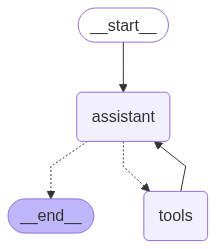

In [ ]:
from IPython.display import Image, display

display(Image(agent.get_graph().draw_mermaid_png()))

#### Create a Function to Run the Chat

Sends the user message to the graph

The checkpointer automatically retrieves the past messages from the session

The LLM generates a response based on full context



In [ ]:
def run_conversation(user_input: str, session_id:str):
    result = agent.invoke(
        {"messages": [HumanMessage(content=user_input)]},
        config={"configurable": {"thread_id": session_id}}  
    )
    for m in result['messages']:
        m.pretty_print()
    
    latest_response = result["messages"][-1].content
    print(f"✅ Agent's Final Response:\n{latest_response}")
    return latest_response



**Testing Our Agent**:

Now that we've built our agent, let's see how it performs with a real-world text example:

We use a chat loop to let the user have a continuous conversation with the assistant.

In [ ]:
run_conversation("what is cholesterol synthesis", "chat-session-001")
